## Short term memory
- Short term memory is useful for storing chat history, user preferences, and other temporary data that can enhance the user experience for the particular conversation/session. it can't store informations across sessions, but it can be used to keep track of the context and state of the conversation within a single session.
### Strategies - 
1. Trimming
2. Summarization

In [32]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from typing import TypedDict, Sequence, Annotated
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END, add_messages, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages.utils import trim_messages, count_tokens_approximately, RemoveMessage

load_dotenv()

True

In [2]:
llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite-preview')

### 1. Trimming

In [4]:
MAX_TOKENS = 100

In [11]:
trim_checkpointer = InMemorySaver()

trim_config = {
    'configurable': {
        'thread_id': 'trimming'
    }
}

In [ ]:
def llm_node(state: MessagesState) -> MessagesState:
    # If no. of tokens in the state['messages'] becomes > 100, it will trimmed, and the llm will only have trimmed messages from the last
    
    trimmed_messages = trim_messages(
        messages = state['messages'],
        strategy = 'last',
        include_system = True,
        end_on = 'human',
        max_tokens = MAX_TOKENS,
        token_counter = count_tokens_approximately
    )

    res = llm.invoke(trimmed_messages)

    return {'messages': [res]}

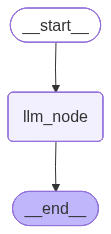

In [7]:
trim_graph = StateGraph(MessagesState)

trim_graph.add_node('llm_node', llm_node)

trim_graph.add_edge(START, 'llm_node')
trim_graph.add_edge('llm_node', END)

trim_workflow = trim_graph.compile(checkpointer=trim_checkpointer)
trim_workflow

In [12]:
res = trim_workflow.invoke({'messages' : [HumanMessage(content='Hi, My name is Mainak')]}, config=trim_config)
res

{'messages': [HumanMessage(content='Hi, My name is Mainak', additional_kwargs={}, response_metadata={}, id='79a58a1c-37b5-4c90-b62f-181c2734b583'),
  AIMessage(content=[{'type': 'text', 'text': "Hi Mainak! It's nice to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgEMOdbHM4qj1RdcwB+DYZWP0yyt8JhwpQW/uM7PBz9ceIuttFxp1qq1BgTc2vuGwXt2'}}], additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--1b8258e4-39ab-4360-bfee-bf181393783f-0', usage_metadata={'input_tokens': 8, 'output_tokens': 27, 'total_tokens': 35, 'input_token_details': {'cache_read': 0}})]}

In [14]:
count_tokens_approximately(res['messages'])

73

In [15]:
res = trim_workflow.invoke({'messages' : [HumanMessage(content='Hi, do you know my name?')]}, config=trim_config)

In [16]:
count_tokens_approximately(res['messages'])

132

In [17]:
trim_workflow.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi, My name is Mainak', additional_kwargs={}, response_metadata={}, id='79a58a1c-37b5-4c90-b62f-181c2734b583'), AIMessage(content=[{'type': 'text', 'text': "Hi Mainak! It's nice to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgEMOdbHM4qj1RdcwB+DYZWP0yyt8JhwpQW/uM7PBz9ceIuttFxp1qq1BgTc2vuGwXt2'}}], additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--1b8258e4-39ab-4360-bfee-bf181393783f-0', usage_metadata={'input_tokens': 8, 'output_tokens': 27, 'total_tokens': 35, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='Hi, do you know my name?', additional_kwargs={}, response_metadata={}, id='1879cca2-cb11-444c-a15f-4aae8792d521'), AIMessage(content=[{'type': 'text', 'text

In [18]:
res = trim_workflow.invoke({'messages' : [HumanMessage(content='Hi, do you know my name?')]}, config=trim_config)

res

{'messages': [HumanMessage(content='Hi, My name is Mainak', additional_kwargs={}, response_metadata={}, id='79a58a1c-37b5-4c90-b62f-181c2734b583'),
  AIMessage(content=[{'type': 'text', 'text': "Hi Mainak! It's nice to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgEMOdbHM4qj1RdcwB+DYZWP0yyt8JhwpQW/uM7PBz9ceIuttFxp1qq1BgTc2vuGwXt2'}}], additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--1b8258e4-39ab-4360-bfee-bf181393783f-0', usage_metadata={'input_tokens': 8, 'output_tokens': 27, 'total_tokens': 35, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='Hi, do you know my name?', additional_kwargs={}, response_metadata={}, id='1879cca2-cb11-444c-a15f-4aae8792d521'),
  AIMessage(content=[{'type': 'text', 'text': 'Yes, you ju

In [19]:
count_tokens_approximately(res['messages'])

273

In [ ]:
res['messages'][-1].content # As the no of tokens became > 100, the previous messages are trimmed and the llm did not find my name, while answering the previous question

[{'type': 'text',
  'text': 'I don\'t actually have access to your personal information, identity, or past conversations unless you provide them in this specific chat session. \n\nIf we have interacted before, I don\'t "remember" you because I don\'t have a long-term memory of our previous chats. If you\'d like, you can tell me your name, and I will be happy to use it during our conversation today!',
  'extras': {'signature': 'EjQKMgEMOdbHxV04egSMOwl0I4nTBfGuj1Vq5ngls5bNWGmvBNT3HRqecQpHXNYpswt4VrkX'}}]

### 2. Summarization

In [3]:
MAX_TOKENS = 500

In [4]:
class AgentState(MessagesState):
    summary: Annotated[str, 'Summary of the previous conversation']

In [5]:
summarization_prompt = ChatPromptTemplate.from_messages([
    ('system', """
You are a memory management assistant for a conversational AI system.

Your task is to create a concise and structured summary of the conversation so far, considering the previous summary (if eny, can be empty), preserving only the most important information needed for future responses.

Guidelines:
- Retain key facts, user preferences, goals, and important context.
- Keep technical details that may affect future reasoning or outputs.
- Remove redundant, repetitive, or irrelevant information.
- Compress the information without losing meaning.
- Maintain clarity and coherence.
- Write the summary in third person.
- Use bullet points when helpful.

Important:
- Do NOT include greetings, filler text, or small talk.
- Do NOT hallucinate or add new information.
- Only summarize what is explicitly present in the conversation and in the previous summary (if any).

Output format:
A compact, structured textual summary that can be reused as context for future prompts.
"""),
('user', 'Summarize the converstation: {conversation}\nPrevious summary: {summary}')
])


In [74]:
mock_converstion = [
    HumanMessage(content='Hi, My name is Mainak'),
    AIMessage(content='Hello Mainak, nice to meet you! How can I assist you today?'),
    HumanMessage(content='Hi, My name is Mainak'),
    AIMessage(content='Hello Mainak, nice to meet you! How can I assist you today?'),
]

In [75]:
llm.invoke(summarization_prompt.invoke({'conversation': mock_converstion, 'summary': 'User loves sports'}))

AIMessage(content=[{'type': 'text', 'text': "- User's name is Mainak.\n- User loves sports.", 'extras': {'signature': 'EjQKMgEMOdbHbWW4wmG5rCLNMaH1BJq9q6w9gEfkeltm60nf2O1GOYPvheTB3jim12l5uwJQ'}}], additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--f5ed9e7c-96dd-4372-aa78-2767b704e75b-0', usage_metadata={'input_tokens': 319, 'output_tokens': 15, 'total_tokens': 334, 'input_token_details': {'cache_read': 0}})

In [6]:
checkpointer = InMemorySaver()

config = {
    'configurable': {
        'thread_id': 'summarization'
    }
}

In [28]:
def summarization_node(state: AgentState) -> AgentState:
    if count_tokens_approximately(state['messages']) <= MAX_TOKENS:
        return {'summary': state['summary']}
    
    prev_summary = state['summary']

    messages = state['messages']

    if isinstance(state['messages'][-1], HumanMessage):
        messages = state['messages'][:-1]  # Skipping the last message (user question)
    
    # If the first message is a system message, we can keep it as it might contain important context for summarization. So we will start summarization from the second message.
    if messages and isinstance(messages[0], SystemMessage):
        messages = messages[1:]

    to_be_summarized = []
    total_tokens = 0

    for message in messages:
        message_tokens = count_tokens_approximately([message])
        if total_tokens + message_tokens > MAX_TOKENS:
            break
        to_be_summarized.append(message)
        total_tokens += message_tokens

    


    new_summary = llm.invoke(summarization_prompt.invoke({'conversation': to_be_summarized, 'summary': prev_summary}))


    # The message ids which are passed to RemoveMessage will be removed from the state, and the new summary will be added to the state. This way we are able to keep the state within the token limit, while still preserving the important information in the summary.
    return {'summary': new_summary, 'messages': [RemoveMessage(id=message.id) for message in to_be_summarized]}
    

In [8]:
def llm_node(state: AgentState) -> AgentState:
    # The llm node can now use the summary in the state for better responses, especially when the conversation is long.
    messages = []
    if state['summary']:
        messages.append(    
            SystemMessage(content=f"Summary of conversation so far: {state['summary']}"),
        )
    
    messages.extend(state['messages'])

    res = llm.invoke(messages)
    
    return {'messages': [res]}

In [9]:
graph = StateGraph(AgentState)

graph.add_node('summarization_node', summarization_node)
graph.add_node('llm_node', llm_node)

graph.add_edge(START, 'summarization_node')
graph.add_edge('summarization_node', 'llm_node')
graph.add_edge('llm_node', END)

app = graph.compile(checkpointer=checkpointer)

In [10]:
app.invoke({'summary': '', 'messages' : [HumanMessage(content='Hi, My name is Mainak')]}, config=config)

{'messages': [HumanMessage(content='Hi, My name is Mainak', additional_kwargs={}, response_metadata={}, id='998724e2-27d2-4662-92f7-e87193827221'),
  AIMessage(content=[{'type': 'text', 'text': "Hi Mainak! It's nice to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgEMOdbHglxR7nwBdWKzkaUnG7ViuO1i+c+1s+QhYMj7QUn/p/uInPgVPw5M86z7uUF/'}}], additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--0320ed65-57de-4dc0-8e12-28b6c9cbef74-0', usage_metadata={'input_tokens': 8, 'output_tokens': 27, 'total_tokens': 35, 'input_token_details': {'cache_read': 0}})],
 'summary': ''}

In [11]:
res = app.invoke({'messages' : [HumanMessage(content='What is the capital of France?')]}, config=config)

res

{'messages': [HumanMessage(content='Hi, My name is Mainak', additional_kwargs={}, response_metadata={}, id='998724e2-27d2-4662-92f7-e87193827221'),
  AIMessage(content=[{'type': 'text', 'text': "Hi Mainak! It's nice to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgEMOdbHglxR7nwBdWKzkaUnG7ViuO1i+c+1s+QhYMj7QUn/p/uInPgVPw5M86z7uUF/'}}], additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--0320ed65-57de-4dc0-8e12-28b6c9cbef74-0', usage_metadata={'input_tokens': 8, 'output_tokens': 27, 'total_tokens': 35, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='473daf82-c5a8-49f1-b589-11c42e37481a'),
  AIMessage(content=[{'type': 'text', 'text': 'The c

In [12]:
count_tokens_approximately(res['messages'])

132

In [13]:
res = app.invoke({'messages' : [HumanMessage(content='What is my name?')]}, config=config)

res

{'messages': [HumanMessage(content='Hi, My name is Mainak', additional_kwargs={}, response_metadata={}, id='998724e2-27d2-4662-92f7-e87193827221'),
  AIMessage(content=[{'type': 'text', 'text': "Hi Mainak! It's nice to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgEMOdbHglxR7nwBdWKzkaUnG7ViuO1i+c+1s+QhYMj7QUn/p/uInPgVPw5M86z7uUF/'}}], additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--0320ed65-57de-4dc0-8e12-28b6c9cbef74-0', usage_metadata={'input_tokens': 8, 'output_tokens': 27, 'total_tokens': 35, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='473daf82-c5a8-49f1-b589-11c42e37481a'),
  AIMessage(content=[{'type': 'text', 'text': 'The c

In [14]:
count_tokens_approximately(res['messages'])

183

In [15]:
res = app.invoke({'messages' : [HumanMessage(content='I am a Jr. Software Engineer in Cognizant. I love working on challenging projects and learning new technologies.')]}, config=config)

In [16]:
res

{'messages': [HumanMessage(content='Hi, My name is Mainak', additional_kwargs={}, response_metadata={}, id='998724e2-27d2-4662-92f7-e87193827221'),
  AIMessage(content=[{'type': 'text', 'text': "Hi Mainak! It's nice to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgEMOdbHglxR7nwBdWKzkaUnG7ViuO1i+c+1s+QhYMj7QUn/p/uInPgVPw5M86z7uUF/'}}], additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--0320ed65-57de-4dc0-8e12-28b6c9cbef74-0', usage_metadata={'input_tokens': 8, 'output_tokens': 27, 'total_tokens': 35, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='473daf82-c5a8-49f1-b589-11c42e37481a'),
  AIMessage(content=[{'type': 'text', 'text': 'The c

In [17]:
res = app.invoke({'messages' : [HumanMessage(content='I am a big fan of Cristiano Ronaldo, and I love watching sports.')]}, config=config)

In [18]:
res

{'messages': [HumanMessage(content='Hi, My name is Mainak', additional_kwargs={}, response_metadata={}, id='998724e2-27d2-4662-92f7-e87193827221'),
  AIMessage(content=[{'type': 'text', 'text': "Hi Mainak! It's nice to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgEMOdbHglxR7nwBdWKzkaUnG7ViuO1i+c+1s+QhYMj7QUn/p/uInPgVPw5M86z7uUF/'}}], additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--0320ed65-57de-4dc0-8e12-28b6c9cbef74-0', usage_metadata={'input_tokens': 8, 'output_tokens': 27, 'total_tokens': 35, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='473daf82-c5a8-49f1-b589-11c42e37481a'),
  AIMessage(content=[{'type': 'text', 'text': 'The c

In [19]:
app.invoke({'messages' : [HumanMessage(content='What is my profession?')]}, config=config)

{'messages': [AIMessage(content=[{'type': 'text', 'text': 'That’s awesome! If you’re a Cristiano Ronaldo fan, you appreciate the definition of hard work, discipline, and constant evolution—which actually mirrors the mindset you need as a Software Engineer. Just like CR7 is always refining his game and staying at the top level despite all the years, in tech, we always have to keep "upskilling" to stay relevant.\n\nSince you love sports and CR7, do you have a favorite team you follow, or do you mostly tune in to watch him play regardless of the club? \n\nAlso, have you ever noticed similarities between sports and programming? I find that the "flow state" you get when you\'re deeply engrossed in a difficult piece of code is somewhat similar to the focus an athlete needs during a high-stakes match!', 'extras': {'signature': 'EjQKMgEMOdbHjx6aXvb7HrSfDr9pVcc8d/9OEo+WmC3iX1tFcztyLmWKKk+sKckyo58Ej1Gi'}}], additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_r

In [20]:
res = app.invoke({'messages' : [HumanMessage(content='Suggest me some best cars under 15 lakhs in India')]}, config=config)

In [21]:
res

{'messages': [AIMessage(content=[{'type': 'text', 'text': 'That’s awesome! If you’re a Cristiano Ronaldo fan, you appreciate the definition of hard work, discipline, and constant evolution—which actually mirrors the mindset you need as a Software Engineer. Just like CR7 is always refining his game and staying at the top level despite all the years, in tech, we always have to keep "upskilling" to stay relevant.\n\nSince you love sports and CR7, do you have a favorite team you follow, or do you mostly tune in to watch him play regardless of the club? \n\nAlso, have you ever noticed similarities between sports and programming? I find that the "flow state" you get when you\'re deeply engrossed in a difficult piece of code is somewhat similar to the focus an athlete needs during a high-stakes match!', 'extras': {'signature': 'EjQKMgEMOdbHjx6aXvb7HrSfDr9pVcc8d/9OEo+WmC3iX1tFcztyLmWKKk+sKckyo58Ej1Gi'}}], additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_r

In [27]:
count_tokens_approximately([res['messages'][0]])

225

In [36]:
def print_chat(state: AgentState):
    print("### CHAT MESSAGES ###")
    for message in state['messages']:
        print(f"{message.type.upper()}: {StrOutputParser().invoke(message)}")
    print("-"*50)
    
    print("### SUMMARY ###")
    print(state['summary'])
    print("-"*50)

    print(f"Approx. token count: {count_tokens_approximately(state['messages'])}")

In [ ]:
res = app.invoke({'messages': 'Who am I?'}, config=config)

In [37]:
print_chat(res)

### CHAT MESSAGES ###
AI: Finding a car under ₹15 lakhs (on-road) in India is a great "sweet spot" right now because you get high-end features, good safety ratings, and modern tech. 

Since you are an engineer who values performance and reliability, here are my top picks based on different needs:

### 1. The Performance & Fun-to-Drive Choice: **Volkswagen Virtus / Skoda Slavia**
If you love the "dynamic" feel of driving (similar to the energy of a sports match), these are the best.
*   **Why:** They have arguably the best build quality and high-speed stability in this segment. The 1.0L TSI engine is punchy, and the ride quality is top-notch.
*   **Best for:** Someone who values driving dynamics and a premium, clean design.

### 2. The Tech-Loaded All-Rounder: **Hyundai Creta / Kia Seltos**
These are the kings of the mid-size SUV segment for a reason.
*   **Why:** If you like gadgets, these cars are packed with them—panoramic sunroofs, ventilated seats, premium sound systems, and advanc